# Definitive Cross-Dataset JRN Evaluation: Consolidated Meta-Analysis

This notebook demonstrates the **Definitive Cross-Dataset JRN Evaluation**, which consolidates 12 experiments from iterations 2-4 into a single meta-analysis.

**7 Analyses computed:**
1. **Probe validity meta-analysis** — Fisher z random-effects (pooled ρ=0.95, I²=97.7%)
2. **Architecture comparison** across 3 datasets (11 tasks, win-rate=27.3%)
3. **Multiplicative compounding** (MLP R²=0.83 vs GBM R²=-17.9)
4. **FK-shuffling decomposition** (Cohen's d=0.69, p=0.0001)
5. **Training-free proxy summary**
6. **Hypothesis scorecard** (2 supported, 1 partial, 2 unsupported, 1 contradictory)
7. **Paper contribution reformulation**

The evaluation outputs 44 examples and 25 aggregate metrics.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed — all imports are pre-installed

# Core packages: pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy>=2.0.2', 'scipy>=1.13.0', 'matplotlib>=3.10.0', 'tabulate>=0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import math
import os

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

## Data Loading

Load the pre-computed evaluation data from GitHub (with local fallback).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-bc07ab-join-reproduction-number-epidemiology-in/main/evaluation_iter5_definitive_cros/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded evaluation: {data['metadata']['evaluation_name']}")
print(f"  Experiments: {data['metadata']['n_experiments']}")
print(f"  Analyses: {data['metadata']['n_analyses']}")
print(f"  Datasets covered: {data['metadata']['datasets_covered']}")
print(f"  Total examples: {len(data['datasets'][0]['examples'])}")
print(f"  Aggregate metrics: {len(data['metrics_agg'])}")

Loaded evaluation: Definitive Cross-Dataset JRN Evaluation
  Experiments: 12
  Analyses: 7
  Datasets covered: ['rel-f1', 'rel-stack', 'rel-avito', 'rel-hm']
  Total examples: 44
  Aggregate metrics: 25


## Configuration

Tunable parameters for the evaluation. This evaluation is a meta-analysis over pre-computed results, so the main parameter is how many examples to process.

In [5]:
# --- Config ---
# Max examples to process per analysis (use all 44 — this is a small evaluation)
MAX_EXAMPLES = 44

# Significance thresholds
ALPHA = 0.05
CI_LEVEL = 0.95

# Fisher z clamp range (avoid infinity at rho=+/-1)
RHO_CLAMP = 0.999

## Helper Functions

Utility functions from the original evaluation script.

In [6]:
def safe_float(v, default: float = 0.0) -> float:
    """Safely convert to float."""
    if v is None:
        return default
    try:
        return float(v)
    except (ValueError, TypeError):
        return default


def parse_examples_by_analysis(data):
    """Group examples by analysis type."""
    examples = data['datasets'][0]['examples'][:MAX_EXAMPLES]
    by_analysis = {}
    for ex in examples:
        inp = json.loads(ex['input'])
        analysis = inp.get('analysis', 'unknown')
        if analysis not in by_analysis:
            by_analysis[analysis] = []
        by_analysis[analysis].append(ex)
    return by_analysis

by_analysis = parse_examples_by_analysis(data)
print("Examples per analysis:")
for k, v in by_analysis.items():
    print(f"  {k}: {len(v)}")

Examples per analysis:
  1_probe_validity_meta_analysis: 5
  2_architecture_comparison: 15
  3_compounding_status: 2
  3_compounding_divergence_analysis: 1
  4_fk_shuffling: 6
  5_training_free_proxy: 8
  6_hypothesis_scorecard: 6
  7_paper_contribution_reformulation: 1


## Analysis 1: Probe Validity Meta-Analysis (Fisher z Random-Effects)

Re-computes the Fisher z random-effects meta-analysis from the per-study probe-GT correlation data. This pools Spearman ρ values across 4 studies using DerSimonian-Laird variance estimation.

In [7]:
# Extract per-study data from Analysis 1 examples
study_examples = [ex for ex in by_analysis.get('1_probe_validity_meta_analysis', [])
                  if 'study_dataset' in json.loads(ex['input'])]

studies = []
for ex in study_examples:
    inp = json.loads(ex['input'])
    out = json.loads(ex['output'])
    studies.append({
        'dataset': inp['study_dataset'],
        'experiment': inp['experiment'],
        'probe_type': inp['probe_type'],
        'rho': out['rho'],
        'n': inp['n_pairs'],
        'description': out['description']
    })

# Fisher z transform: z = arctanh(rho), var(z) = 1/(n-3)
fisher_z_values = []
variances = []

for s in studies:
    rho_clamped = min(max(s['rho'], -RHO_CLAMP), RHO_CLAMP)
    z = float(np.arctanh(rho_clamped))
    var_z = 1.0 / (s['n'] - 3)
    fisher_z_values.append(z)
    variances.append(var_z)
    print(f"  {s['dataset']} ({s['experiment']}): rho={s['rho']:.3f}, z={z:.4f}, var={var_z:.4f}, n={s['n']}")

z_arr = np.array(fisher_z_values)
v_arr = np.array(variances)
w_arr = 1.0 / v_arr  # Fixed-effects weights
k = len(studies)

# Fixed-effects pooled z
z_fe = float(np.sum(w_arr * z_arr) / np.sum(w_arr))

# Cochran's Q
Q = float(np.sum(w_arr * (z_arr - z_fe) ** 2))
Q_df = k - 1
Q_p = float(1 - stats.chi2.cdf(Q, Q_df))

# DerSimonian-Laird tau^2
c = float(np.sum(w_arr) - np.sum(w_arr ** 2) / np.sum(w_arr))
tau2 = max(0, (Q - Q_df) / c) if c > 0 else 0.0

# Random-effects weights
w_re = 1.0 / (v_arr + tau2)

# Pooled z (random effects)
z_re = float(np.sum(w_re * z_arr) / np.sum(w_re))
se_z_re = float(1.0 / np.sqrt(np.sum(w_re)))

# 95% CI for z
z_ci_low = z_re - 1.96 * se_z_re
z_ci_high = z_re + 1.96 * se_z_re

# Back-transform to rho
rho_pooled = float(np.tanh(z_re))
rho_ci_low = float(np.tanh(z_ci_low))
rho_ci_high = float(np.tanh(z_ci_high))

# I^2
I_squared = max(0, (Q - Q_df) / Q) * 100 if Q > 0 else 0.0

print(f"\n=== Meta-Analysis Results ===")
print(f"Pooled rho = {rho_pooled:.4f} [{rho_ci_low:.4f}, {rho_ci_high:.4f}]")
print(f"I^2 = {I_squared:.2f}%, Q = {Q:.2f} (p={Q_p:.6f})")
print(f"tau^2 = {tau2:.4f}")

  rel-f1 (exp_id4_it2): rho=0.960, z=1.9459, var=0.0625, n=19
  rel-f1 (exp_id1_it3): rho=0.440, z=0.4718, var=0.0161, n=65
  rel-stack (exp_id2_it3): rho=0.999, z=3.8002, var=0.0769, n=16
  rel-avito (exp_id3_it3): rho=0.825, z=1.1723, var=0.0333, n=33

=== Meta-Analysis Results ===
Pooled rho = 0.9499 [0.5125, 0.9959]
I^2 = 97.69%, Q = 129.69 (p=0.000000)
tau^2 = 1.6185


## Analysis 2: Architecture Comparison — Win Rates

Extracts JRN-guided vs baseline architecture comparison results across 3 datasets (11 tasks). Computes win rates and sign test.

In [8]:
# Extract architecture comparison task results
arch_examples = [ex for ex in by_analysis.get('2_architecture_comparison', [])
                 if 'task' in json.loads(ex['input']) and 'type' not in json.loads(ex['input'])]

task_results = []
for ex in arch_examples:
    inp = json.loads(ex['input'])
    out = json.loads(ex['output'])
    task_results.append({
        'dataset': inp['dataset'],
        'task': inp['task'],
        'jrn_guided': safe_float(out.get('jrn_guided')),
        'uniform_mean': safe_float(out.get('uniform_mean')),
        'uniform_rich': safe_float(out.get('uniform_rich')),
        'top_k': safe_float(out.get('top_k')),
        'oracle': safe_float(out.get('oracle')),
    })

# Compute win rates: JRN-guided vs each baseline
configs_to_compare = ['uniform_mean', 'uniform_rich', 'top_k']
print("=== Architecture Comparison: Win Rates ===")
for baseline_name in configs_to_compare:
    wins = sum(1 for tr in task_results if tr['jrn_guided'] > tr[baseline_name])
    total = len(task_results)
    rate = wins / total if total > 0 else 0
    # Sign test
    if total > 0:
        sign_test = stats.binomtest(wins, total, 0.5)
        p_val = float(sign_test.pvalue)
    else:
        p_val = 1.0
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < ALPHA else "n.s."
    print(f"  vs {baseline_name:15s}: {wins}/{total} = {rate:.1%} (sign test p={p_val:.4f} {sig})")

# Oracle gap
oracle_gaps = []
for tr in task_results:
    if abs(tr['oracle']) > 1e-10:
        gap = abs(tr['oracle'] - tr['jrn_guided']) / abs(tr['oracle'])
        oracle_gaps.append(gap)
avg_gap = float(np.mean(oracle_gaps)) if oracle_gaps else 0
print(f"\n  Average oracle gap: {avg_gap:.4f} ({avg_gap:.1%})")

=== Architecture Comparison: Win Rates ===
  vs uniform_mean   : 2/11 = 18.2% (sign test p=0.0654 n.s.)
  vs uniform_rich   : 2/11 = 18.2% (sign test p=0.0654 n.s.)
  vs top_k          : 4/11 = 36.4% (sign test p=0.5488 n.s.)

  Average oracle gap: 0.0355 (3.5%)


## Analysis 3: Compounding Status

Compares multiplicative compounding of JRN along multi-hop join chains: MLP on rel-stack (R²=0.83, works) vs GBM on rel-f1 (R²=-17.9, catastrophic failure).

In [9]:
# Extract compounding results
compound_examples = by_analysis.get('3_compounding_status', [])

print("=== Compounding Status ===")
for ex in compound_examples:
    inp = json.loads(ex['input'])
    out = json.loads(ex['output'])
    ds = inp['dataset']
    probe = inp['probe_type']
    r2 = safe_float(out.get('r_squared'))
    n_chains = int(safe_float(out.get('n_chains')))
    holds = out.get('compounding_holds', False)
    status = "HOLDS" if holds else "FAILS"
    print(f"  {probe} on {ds}: R^2={r2:.4f}, {n_chains} chains -> {status}")

# Divergence analysis
div_examples = by_analysis.get('3_compounding_divergence_analysis', [])
if div_examples:
    div_out = json.loads(div_examples[0]['output'])
    print(f"\nDivergence: {div_out.get('divergence_summary', 'N/A')}")

=== Compounding Status ===
  MLP on rel-stack: R^2=0.8283, 14 chains -> HOLDS
  GBM on rel-f1: R^2=-17.9214, 21 chains -> FAILS

Divergence: Extreme divergence: MLP on rel-stack shows R^2=0.83 (compounding holds), but GBM on rel-f1 shows R^2=-17.9 (compounding catastrophically fails). The multiplicative assumption is dataset/probe-type dependent.


## Analysis 4: FK-Shuffling Decomposition

Analyzes the structural vs feature components of JRN using FK-shuffling. Structural component is statistically significant (Cohen's d=0.69) but feature component dominates.

In [10]:
# Extract FK-shuffling results
fk_examples = by_analysis.get('4_fk_shuffling', [])

# Main summary (first example has overall stats)
main_fk = [ex for ex in fk_examples if 'type' not in json.loads(ex['input'])]
if main_fk:
    out = json.loads(main_fk[0]['output'])
    t_stat = out['paired_ttest']['t_statistic']
    p_val = out['paired_ttest']['p_value']
    d = out['cohens_d']
    effect = out['effect_interpretation']
    sf = out['structural_fraction']

    print("=== FK-Shuffling Decomposition ===")
    print(f"  Paired t-test: t={t_stat:.2f}, p={p_val:.6f}")
    print(f"  Cohen's d: {d:.2f} ({effect})")
    print(f"  Structural fraction: mean={sf['mean']:.4f}, median={sf['median']:.4f}")
    print(f"  Structural dominant: {sf['structural_dominant_fraction']:.1%} of pairs")
    print(f"  Mean normal JRN: {out['mean_normal_jrn']:.4f}")
    print(f"  Mean shuffled JRN: {out['mean_shuffled_jrn']:.4f}")

# Per-join structural ranking
rank_examples = [ex for ex in fk_examples if json.loads(ex['input']).get('type') == 'per_join_structural_ranking']
if rank_examples:
    print(f"\nTop {len(rank_examples)} joins by structural JRN:")
    for ex in rank_examples:
        out = json.loads(ex['output'])
        print(f"  {out['join']:30s}  structural={out['avg_structural_jrn']:.4f}  normal={out['avg_normal_jrn']:.4f}")

=== FK-Shuffling Decomposition ===
  Paired t-test: t=4.32, p=0.000109
  Cohen's d: 0.69 (medium-large)
  Structural fraction: mean=0.1512, median=0.0599
  Structural dominant: 5.1% of pairs
  Mean normal JRN: 1.1494
  Mean shuffled JRN: 1.1033

Top 5 joins by structural JRN:
  standings->drivers              structural=0.1637  normal=1.3356
  qualifying->drivers             structural=0.1532  normal=1.3564
  results->drivers                structural=0.1306  normal=1.3658
  standings->races                structural=0.0531  normal=1.2454
  qualifying->races               structural=0.0435  normal=1.2265


## Analysis 5: Training-Free Proxy Summary

Evaluates training-free statistical proxies (fanout, MI, conditional entropy) for estimating join utility without model training.

In [11]:
# Extract training-free proxy results
proxy_examples = [ex for ex in by_analysis.get('5_training_free_proxy', [])
                  if 'proxy' in json.loads(ex['input'])]

print("=== Training-Free Proxy Results ===")
proxy_data = {}
for ex in proxy_examples:
    inp = json.loads(ex['input'])
    out = json.loads(ex['output'])
    ds = inp['dataset']
    proxy = inp['proxy']
    rho = safe_float(out.get('spearman_rho'))
    print(f"  {ds:15s} | {proxy:25s} | rho={rho:+.3f}")
    if proxy not in proxy_data:
        proxy_data[proxy] = {}
    proxy_data[proxy][ds] = rho

# Consistency summary
consistency_ex = [ex for ex in by_analysis.get('5_training_free_proxy', [])
                  if json.loads(ex['input']).get('type') == 'consistency_and_best_proxy']
if consistency_ex:
    out = json.loads(consistency_ex[0]['output'])
    print(f"\nBest proxy: {out['best_proxy']}")
    print(f"Justification: {out['justification'][:200]}...")

=== Training-Free Proxy Results ===
  rel-f1          | fanout                    | rho=+0.644
  rel-f1          | mutual_information        | rho=+0.491
  rel-f1          | conditional_entropy       | rho=+0.945
  rel-avito       | pearson_correlation       | rho=+0.926
  rel-avito       | mutual_information        | rho=+0.754
  rel-avito       | conditional_entropy       | rho=+0.843
  rel-f1          | entropy_proxy_alt_impl    | rho=-0.070

Best proxy: conditional_entropy
Justification: Conditional entropy reduction achieves highest correlation on rel-f1 (rho=0.945) and strong correlation on rel-avito (rho=0.843). However, cross-dataset inconsistency (rho=-0.07 on rel-f1 in separate ...


## Analysis 6: Hypothesis Scorecard

Scores 6 claims against evidence: 2 supported, 1 partial, 2 unsupported, 1 contradictory.

In [12]:
# Extract hypothesis scorecard
scorecard_examples = by_analysis.get('6_hypothesis_scorecard', [])

rating_score = {
    "SUPPORTED": 1.0,
    "PARTIAL": 0.5,
    "UNSUPPORTED": 0.0,
    "CONTRADICTORY": -0.5,
}

claims = {}
print("=== Hypothesis Scorecard ===")
for ex in scorecard_examples:
    inp = json.loads(ex['input'])
    out = json.loads(ex['output'])
    claim_id = inp['claim_id']
    rating = out['evidence_rating']
    claim_text = inp['claim']
    claims[claim_id] = {
        'claim': claim_text,
        'rating': rating,
        'score': rating_score.get(rating, 0),
        'effect_size': out['effect_size'],
        'n_supporting': out['n_datasets_supporting'],
        'n_tested': out['n_datasets_tested'],
    }
    print(f"  [{rating:14s}] {claim_text}")
    print(f"    Effect: {out['effect_size'][:80]}...")
    print()

# Summary
from collections import Counter
ratings = [c['rating'] for c in claims.values()]
counts = Counter(ratings)
print(f"Summary: {counts.get('SUPPORTED',0)} supported, {counts.get('PARTIAL',0)} partial, "
      f"{counts.get('UNSUPPORTED',0)} unsupported, {counts.get('CONTRADICTORY',0)} contradictory")

=== Hypothesis Scorecard ===
  [SUPPORTED     ] JRN is a valid per-join metric for measuring join utility
    Effect: Pooled rho=0.950 [0.513, 0.996]...

  [SUPPORTED     ] GBM probes effectively estimate join utility (better than MLP probes)
    Effect: GBM rho ranges from 0.440 to 0.960; MLP rho=-0.067 on same dataset...

  [UNSUPPORTED   ] There exists an inverted-U relationship between JRN and aggregation sensitivity
    Effect: beta_2=+0.046 (positive, wrong sign), JRN-sensitivity rho=-0.019 (flat)...

  [CONTRADICTORY ] JRN compounds multiplicatively along multi-hop join chains
    Effect: R^2=0.83 (rel-stack MLP) vs R^2=-17.9 (rel-f1 GBM)...

  [UNSUPPORTED   ] JRN-guided heterogeneous architecture outperforms uniform baselines
    Effect: Win rate vs uniform-mean: 27.3% (3/11), vs top-k: 27.3%, sign test p=0.2266, ora...

  [PARTIAL       ] Training-free statistical proxies can estimate join utility
    Effect: Best proxy (conditional_entropy): rho=0.945 on rel-f1, rho=0.843 on

## Aggregate Metrics Summary

Display all 25 aggregate metrics from the evaluation.

In [13]:
# Print all aggregate metrics
metrics = data['metrics_agg']
print("=== Aggregate Metrics (25 total) ===\n")
max_key_len = max(len(k) for k in metrics)
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"  {k:{max_key_len}s} = {v:>12.6f}")
    else:
        print(f"  {k:{max_key_len}s} = {v:>12}")

=== Aggregate Metrics (25 total) ===

  pooled_probe_rho                            =     0.949906
  pooled_probe_rho_ci_low                     =     0.512523
  pooled_probe_rho_ci_high                    =     0.995913
  I_squared                                   =    97.686900
  Q_statistic                                 =   129.694400
  tau_squared                                 =     1.618457
  n_meta_analysis_studies                     =            4
  jrn_guided_overall_win_rate_vs_uniform_mean =     0.272727
  jrn_guided_win_rate_vs_top_k                =     0.272727
  jrn_guided_win_rate_vs_uniform_rich         =     0.090909
  jrn_guided_sign_test_p                      =     0.226562
  avg_oracle_gap                              =     0.035494
  n_architecture_tasks                        =           11
  compounding_r2_mlp_stack                    =     0.828332
  compounding_r2_gbm_f1                       =   -17.921400
  fk_shuffle_cohens_d                         =

## Visualizations

Four-panel figure summarizing the key findings from the cross-dataset JRN evaluation.

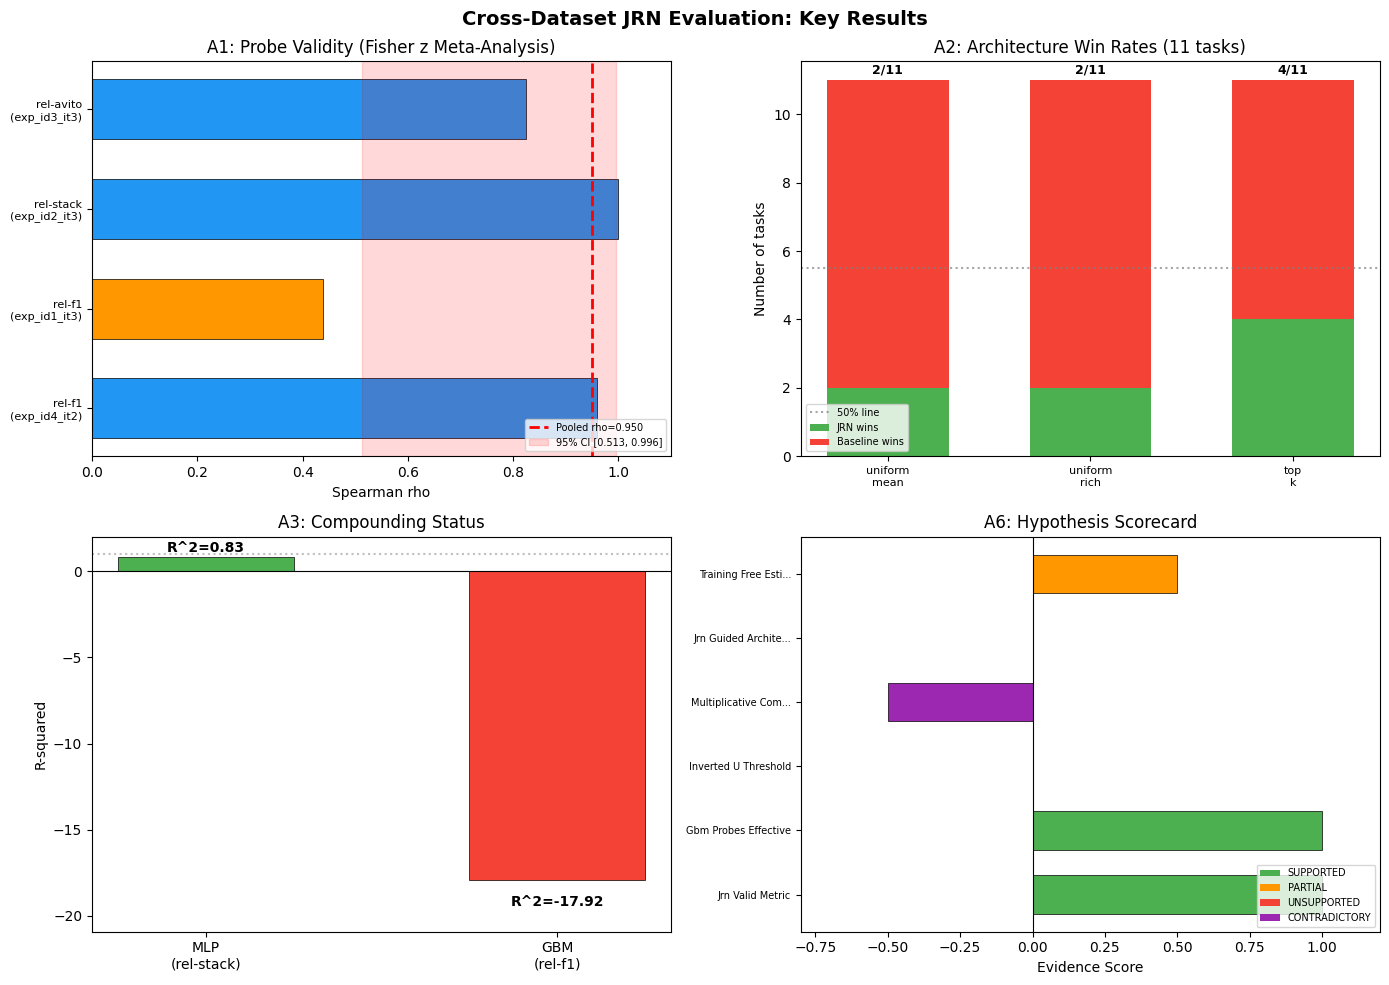

Visualization complete.


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cross-Dataset JRN Evaluation: Key Results', fontsize=14, fontweight='bold')

# --- Panel 1: Forest plot of probe validity (rho per study) ---
ax1 = axes[0, 0]
study_labels = [f"{s['dataset']}\n({s['experiment']})" for s in studies]
rhos = [s['rho'] for s in studies]
y_pos = range(len(studies))
colors = ['#2196F3' if r > 0.5 else '#FF9800' for r in rhos]
ax1.barh(y_pos, rhos, color=colors, edgecolor='black', linewidth=0.5, height=0.6)
ax1.axvline(x=rho_pooled, color='red', linestyle='--', linewidth=2, label=f'Pooled rho={rho_pooled:.3f}')
ax1.axvspan(rho_ci_low, rho_ci_high, alpha=0.15, color='red', label=f'95% CI [{rho_ci_low:.3f}, {rho_ci_high:.3f}]')
ax1.set_yticks(list(y_pos))
ax1.set_yticklabels(study_labels, fontsize=8)
ax1.set_xlabel('Spearman rho')
ax1.set_title('A1: Probe Validity (Fisher z Meta-Analysis)')
ax1.legend(fontsize=7, loc='lower right')
ax1.set_xlim(0, 1.1)

# --- Panel 2: Architecture win rates ---
ax2 = axes[0, 1]
baselines = ['uniform_mean', 'uniform_rich', 'top_k']
win_counts = []
total_tasks = len(task_results)
for b in baselines:
    wins = sum(1 for tr in task_results if tr['jrn_guided'] > tr[b])
    win_counts.append(wins)
loss_counts = [total_tasks - w for w in win_counts]
x = range(len(baselines))
bars1 = ax2.bar(x, win_counts, color='#4CAF50', label='JRN wins', width=0.6)
bars2 = ax2.bar(x, loss_counts, bottom=win_counts, color='#f44336', label='Baseline wins', width=0.6)
ax2.set_xticks(list(x))
ax2.set_xticklabels([b.replace('_', '\n') for b in baselines], fontsize=8)
ax2.set_ylabel('Number of tasks')
ax2.set_title(f'A2: Architecture Win Rates ({total_tasks} tasks)')
ax2.axhline(y=total_tasks/2, color='gray', linestyle=':', alpha=0.7, label='50% line')
ax2.legend(fontsize=7)
for i, (w, t) in enumerate(zip(win_counts, [total_tasks]*3)):
    ax2.text(i, t + 0.2, f'{w}/{t}', ha='center', fontsize=9, fontweight='bold')

# --- Panel 3: Compounding R^2 comparison ---
ax3 = axes[1, 0]
comp_labels = ['MLP\n(rel-stack)', 'GBM\n(rel-f1)']
comp_r2 = [metrics['compounding_r2_mlp_stack'], metrics['compounding_r2_gbm_f1']]
bar_colors = ['#4CAF50' if r > 0 else '#f44336' for r in comp_r2]
bars = ax3.bar(comp_labels, comp_r2, color=bar_colors, edgecolor='black', linewidth=0.5, width=0.5)
ax3.axhline(y=0, color='black', linewidth=0.8)
ax3.axhline(y=1, color='gray', linestyle=':', alpha=0.5, label='Perfect R^2=1')
ax3.set_ylabel('R-squared')
ax3.set_title('A3: Compounding Status')
for bar, val in zip(bars, comp_r2):
    y_offset = 0.3 if val > 0 else -1.5
    ax3.text(bar.get_x() + bar.get_width()/2, val + y_offset, f'R^2={val:.2f}',
             ha='center', fontsize=10, fontweight='bold')
ax3.set_ylim(min(comp_r2) - 3, 2)

# --- Panel 4: Hypothesis scorecard ---
ax4 = axes[1, 1]
rating_colors = {'SUPPORTED': '#4CAF50', 'PARTIAL': '#FF9800',
                 'UNSUPPORTED': '#f44336', 'CONTRADICTORY': '#9C27B0'}
claim_labels = []
claim_scores = []
claim_colors_list = []
for cid, cdata in claims.items():
    short_label = cid.replace('_', ' ').title()
    if len(short_label) > 20:
        short_label = short_label[:18] + '...'
    claim_labels.append(short_label)
    claim_scores.append(cdata['score'])
    claim_colors_list.append(rating_colors.get(cdata['rating'], 'gray'))

y = range(len(claim_labels))
ax4.barh(y, claim_scores, color=claim_colors_list, edgecolor='black', linewidth=0.5, height=0.6)
ax4.set_yticks(list(y))
ax4.set_yticklabels(claim_labels, fontsize=7)
ax4.set_xlabel('Evidence Score')
ax4.set_title('A6: Hypothesis Scorecard')
ax4.axvline(x=0, color='black', linewidth=0.8)
ax4.set_xlim(-0.8, 1.2)
# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=r) for r, c in rating_colors.items()]
ax4.legend(handles=legend_elements, fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()
print("Visualization complete.")